# Generating Centroid Positions for K-Means Algorithm

K-Means algorithm needs to choose initial centroid positions before clustering begins, there are several methods for generating these initial positions, and choice can significantly affect final result because k-means can get stuck in local minima
- **random initialization** (forgy method) — classic k-means
	- this is simplest method
	- randomly select k data points from dataset
	- use them directly as initial centroids
	- this is fast but sometimes gives poor starting points
- **random partition initialization**
	- randomly assign each data point to one of k clusters
	- compute centroids as mean of each cluster
	- this tends to produce centroids near center of data cloud but can be less stable
- **k-means++ initialization** (default in scikit-learn)
	- this is modern and widely used method because it improves convergence and reduces chance of bad clustering
	- process
		- choose 1st centroid randomly from data
    		- calculate distance between all points and this centroid
		- choose 2nd centroid position using a weighted probability distribution where a point is chosen with probability proportional to distribution of squared distances
    		- compute distance² from each point to nearest already chosen centroid
			- select next centroid with probability proportional to distance²
		- repeat above process to generate all centroids
	- intuition
		- 1st centroid is random
		- next centroids are chosen far apart
		- this spreads centroids in a way that reduces poor initializations
	- result
		- much faster convergence
		- better clustering performance
		- more stable results across runs
- **user-defined initialization**
	- you can manually supply initial centroids
		```python
		kmeans = KMeans(n_clusters=k, init=your_centroid_array)
		```
	- useful when you know something about structure of data

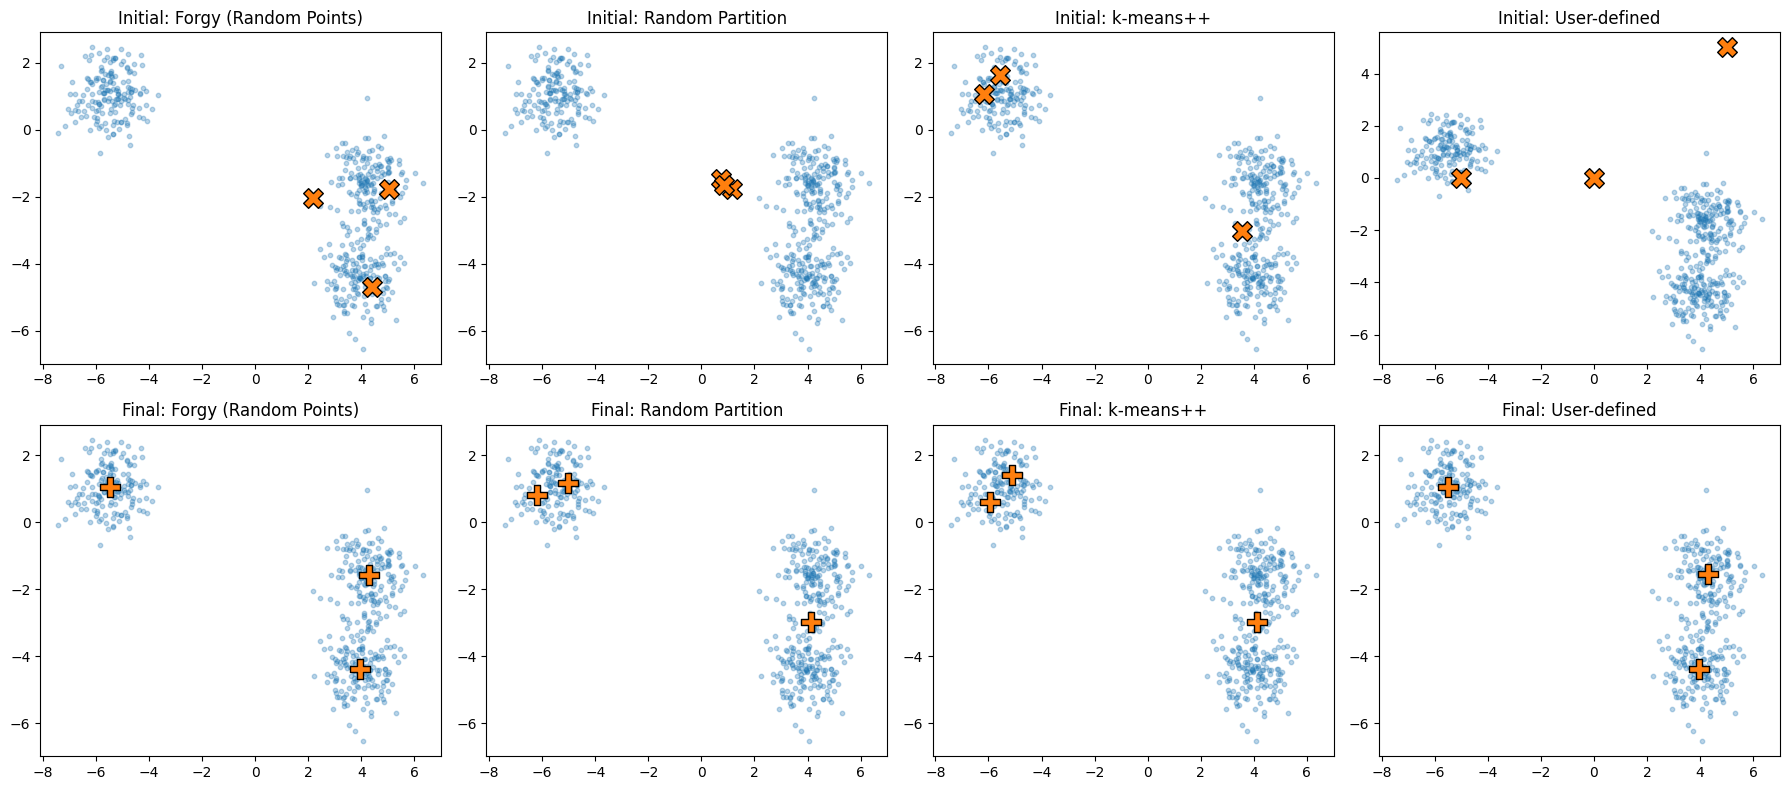

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# =====================================================
# 1. Generate fabricated data
# =====================================================
X, y = make_blobs(
    n_samples=500, centers=3,
    cluster_std=0.7, random_state=123
)

k = 3

# =====================================================
# 2. Initialization Methods
# =====================================================

# --- (A) Random Initialization (Forgy) ---
def init_forgy(X, k):
    idx = np.random.choice(len(X), k, replace=False)
    return X[idx]

# --- (B) Random Partition Initialization ---
def init_random_partition(X, k):
    labels = np.random.randint(0, k, size=len(X))
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

# --- (C) k-means++ Initialization ---
def init_kmeans_plus_plus(X, k):
    n_samples, _ = X.shape
    centroids = []

    # First centroid
    first_idx = np.random.randint(n_samples)
    centroids.append(X[first_idx])

    # Remaining centroids
    for _ in range(1, k):
        dist_sq = np.min(
            np.array([np.sum((X - c) ** 2, axis=1) for c in centroids]),
            axis=0,
        )
        prob = dist_sq / dist_sq.sum()
        next_idx = np.random.choice(n_samples, p=prob)
        centroids.append(X[next_idx])

    return np.array(centroids)

# --- (D) User-defined Initialization ---
user_defined_centroids = np.array([
    [0, 0],
    [5, 5],
    [-5, 0]
])

# =====================================================
# 3. Compute Initial Centroids
# =====================================================
init_methods = {
    "Forgy (Random Points)": init_forgy(X, k),
    "Random Partition": init_random_partition(X, k),
    "k-means++": init_kmeans_plus_plus(X, k),
    "User-defined": user_defined_centroids,
}

# =====================================================
# 4. Run K-means for each initialization method
# =====================================================
final_centroids = {}

for name, init_c in init_methods.items():
    kmeans = KMeans(
        n_clusters=k,
        init=init_c,
        n_init=1,       # MUST be 1 when using manual initialization
        random_state=0
    )
    kmeans.fit(X)
    final_centroids[name] = kmeans.cluster_centers_

# =====================================================
# 5. Plot 2×4 subplots
# =====================================================
fig, axs = plt.subplots(2, 4, figsize=(18, 8))

titles = list(init_methods.keys())

# --- Row 1: Initial centroids ---
for i, title in enumerate(titles):
    ax = axs[0, i]
    ax.scatter(X[:, 0], X[:, 1], s=10, alpha=0.3)
    ax.scatter(init_methods[title][:, 0], init_methods[title][:, 1],
               s=200, marker='X', edgecolor='black')
    ax.set_title(f"Initial: {title}")

# --- Row 2: Final centroids after k-means ---
for i, title in enumerate(titles):
    ax = axs[1, i]
    ax.scatter(X[:, 0], X[:, 1], s=10, alpha=0.3)
    ax.scatter(final_centroids[title][:, 0], final_centroids[title][:, 1],
               s=200, marker='P', edgecolor='black')
    ax.set_title(f"Final: {title}")

plt.tight_layout()
plt.show()


| Method | How centroids are created | Notes |
| :----: | :-----------------------: | :---: |
| Random (Forgy) | Pick k random data points | Fast but may give poor starting points |
| Random Partition | Random cluster assignment → compute means | Rarely used, more variable |
| k-means++ | First centroid random; others chosen with distance² probability | Best balance of speed/stability; default in sklearn |
| Manual | User provides k initial centroids | For domain-specific setups |